##Step 2: Data Collection

###Import Necessary Libraries

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score


###Load Dataset

In [ ]:
college_data = pd.read_csv('college_list.csv')
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9
...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6


##Step3: Data Understanding

###Perform Initial Investigation

In [ ]:
college_data.shape

(500, 6)

In [ ]:
college_data.isna().sum()

,0
College_Name,0
Student_Faculty_Ratio,0
Annual_Fees_INR,0
Placement_Percentage,0
Average_Package_LPA,0
Infrastructure_Score,0


In [ ]:
college_data.dtypes

,0
College_Name,object
Student_Faculty_Ratio,int64
Annual_Fees_INR,int64
Placement_Percentage,int64
Average_Package_LPA,float64
Infrastructure_Score,int64


In [ ]:
college_data.describe()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,18.084000,138763.710000,69.000000,6.991720,5.97600
std,6.683283,63928.678815,17.193465,2.917991,2.00486
min,8.000000,30404.000000,40.000000,2.000000,3.00000
25%,12.000000,82610.500000,53.750000,4.472500,4.00000
50%,18.000000,140290.500000,69.000000,7.155000,6.00000
75%,24.000000,193422.000000,84.000000,9.432500,8.00000
max,29.000000,249930.000000,99.000000,11.990000,9.00000


##Step 4: Data Preparation

In [ ]:
X = college_data.drop(columns='College_Name')
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


In [ ]:
std_scaler = StandardScaler()
Scaled_X = std_scaler.fit_transform(X)
Scaled_X = pd.DataFrame(Scaled_X,columns = X.columns)
Scaled_X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


##Step 5: Model Building

###**Level 1**: Building Clustering

In [ ]:
clusters = KMeans(n_clusters=3,random_state=13)
clusters

KMeans(n_clusters=3, random_state=13)

In [ ]:
clusters_new = clusters.fit(Scaled_X)
clusters_new.labels_

array([2, 0, 0, 0, 2, 0, 1, 1, 2, 1, 0, 1, 1, 2, 0, 0, 2, 0, 1, 1, 1, 2,
       2, 0, 1, 2, 2, 2, 0, 0, 1, 2, 1, 2, 2, 2, 1, 0, 2, 1, 0, 1, 0, 1,
       2, 1, 1, 0, 2, 1, 0, 1, 2, 2, 1, 0, 2, 0, 0, 2, 2, 2, 0, 0, 2, 0,
       1, 0, 2, 0, 1, 0, 1, 0, 1, 2, 1, 1, 2, 2, 1, 2, 0, 1, 2, 1, 0, 1,
       2, 2, 2, 1, 1, 0, 1, 0, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2,
       1, 0, 1, 0, 0, 0, 1, 2, 2, 0, 0, 0, 2, 2, 2, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 2, 2, 2, 1, 0, 1, 1, 0, 1, 0, 0, 1, 2, 0, 0, 1, 0, 1,
       1, 0, 1, 2, 1, 1, 0, 2, 2, 2, 2, 1, 2, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 2, 2, 2, 1, 2, 0, 1, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 0,
       2, 2, 2, 1, 1, 2, 0, 2, 1, 0, 1, 1, 0, 2, 2, 1, 2, 2, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 2, 2, 1, 0, 0, 1, 1, 0, 1, 1, 2, 1, 1, 0, 0, 2, 2,
       0, 0, 2, 2, 1, 2, 2, 0, 1, 0, 1, 0, 1, 2, 1, 1, 1, 1, 2, 2, 1, 0,
       1, 0, 2, 1, 1, 1, 2, 0, 2, 1, 2, 0, 2, 2, 2, 0, 0, 2, 0, 2, 2, 1,
       1, 2, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 2,

In [ ]:
clusters_new.inertia_

1859.7536731110688

###Choose Optimal Number of Clusters

In [ ]:
wcss = []
for i in range(1,11):
  Km_cluster = KMeans(n_clusters=i,random_state=13)
  Km_cluster.fit(Scaled_X)
  wcss.append(Km_cluster.inertia_)


In [ ]:
wcss

[2500.000000000001,
 2124.2378672245854,
 1859.7536731110688,
 1661.8880133488472,
 1476.0182921962594,
 1370.3529396892748,
 1299.5447678259438,
 1198.8168194738248,
 1139.8258832697093,
 1074.751468756883]

###Plot the number of clusters vs wcss to choose optimal number of clusters through elbow curve

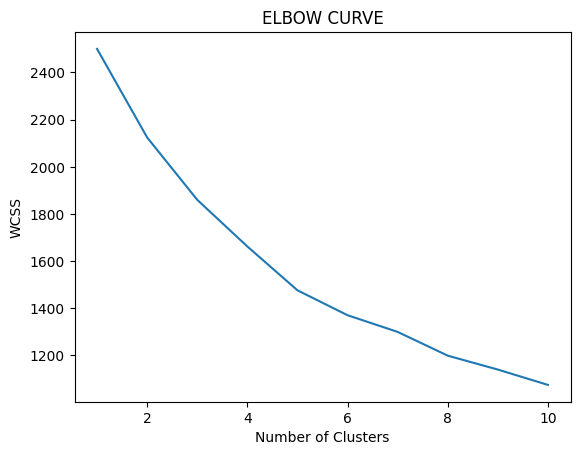

In [ ]:

plt.plot(range(1,11),wcss)
plt.title('ELBOW CURVE')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

###By Elbow Curve, no.of clusters= 3 absolutely good to use in this dataset

###**Level 2:** Updating the clusters in the dataset and perform Data Mining

In [ ]:
college_data['College_Level'] = clusters_new.labels_
college_data.head()

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,2


In [ ]:
X['College_Level'] = clusters_new.labels_

In [ ]:
X.groupby(by='College_Level').agg(['mean'])

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
,mean,mean,mean,mean,mean
College_Level,,,,,
0,23.793333,100069.320000,59.833333,6.938200,6.160000
1,17.629630,143441.042328,86.666667,6.352222,5.634921
2,13.298137,169323.602484,56.801242,7.792298,6.204969


In [ ]:
X.groupby(by='College_Level').agg(['min','max'])

Student_Faculty_Ratio     Annual_Fees_INR          \
                                min max             min     max   
College_Level                                                     
0                                11  29           30404  249536   
1                                 8  29           31015  248803   
2                                 8  26           34621  249930   

              Placement_Percentage     Average_Package_LPA         \
                               min max                 min    max   
College_Level                                                       
0                               40  88                2.01  11.89   
1                               62  99                2.00  11.99   
2                               40  83                2.01  11.92   

              Infrastructure_Score      
                               min max  
College_Level                           
0                                3   9  
1                                3   9  
2                                3   9

In [ ]:
cluster_names = {
    0: 'Mid Level College',
    1: 'Best College',
    2: 'Emerging College'
}

In [ ]:
X['Category'] = X['College_Level'].map(cluster_names)
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level,Category
0,14,113042,59,9.20,8,2,Emerging College
1,27,115999,67,3.07,7,0,Mid Level College
2,22,47955,50,3.40,9,0,Mid Level College
3,18,67841,43,4.64,8,0,Mid Level College
4,15,100640,54,4.66,9,2,Emerging College
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,2,Emerging College
496,12,39111,76,3.62,7,1,Best College
497,16,199182,64,3.88,3,2,Emerging College
498,10,46389,77,9.31,6,1,Best College


###Level 3: Transition to Supervised Machine Learning

###Model Training || Model Evaluation

In [ ]:
input_data = X.drop(columns=['Category','College_Level'])
output_data = X['College_Level']
X_train,X_test,y_train,y_test = train_test_split(input_data,output_data,test_size=0.2,random_state=13,shuffle=True,stratify=output_data)
model = RandomForestClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print('Accuracy_score:',round(accuracy_score(y_test,y_pred),4))
print('Precision_score:',round(precision_score(y_test,y_pred,average='weighted'),4))
print('Recall_score:',round(recall_score(y_test,y_pred,average='weighted'),4))

Accuracy_score: 0.95
Precision_score: 0.951
Recall_score: 0.95


##Model Deployment

In [ ]:
from pickle import dump
dump(model,open('college_data_intel.pkl','wb'))

##THE END!!!